# Project 4, APS1070 Fall 2022
#### **Linear Regression -  14 points**
**Deadline: Dec 1st, 21:00**

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Sudarsanamurthy Tenneti Prabakaramurthy
*   Your **student number**: 1008628601



### How to submit **(HTML [This notebook] + IPYNB + GitHub [Part 7])**

1. Download your notebook: `File -> Download .ipynb`

2. Click on the Files icon on the far left menu of Colab

3. Select & upload your `.ipynb` file you just downloaded, and then obtain its path (right click) (you might need to hit the Refresh button before your file shows up)


4. execute the following in a Colab cell:
```
%%shell
jupyter nbconvert --to html /PATH/TO/YOUR/NOTEBOOKFILE.ipynb
```

5. An HTML version of your notebook will appear in the files, so you can download it.

6. Submit **both** <font color='red'>`HTML` and `IPYNB`</font>  files for this notebook on Quercus for grading.

7. Make sure you compeleted the last part on <font color='red'>**GitHub**</font> and added your link to the last cell here. The teaching team will view and grade your part 7 on GitHub.



Ref: https://stackoverflow.com/a/64487858 



In [ ]:
%%shell
jupyter nbconvert --to html /content/F22_APS1070_Project_4.ipynb

[NbConvertApp] Converting notebook /content/F22_APS1070_Project_4.ipynb to html
[NbConvertApp] Writing 749714 bytes to /content/F22_APS1070_Project_4.html


## Part 1 - Getting Started [1 marks]

Ailerons are small hinged sections on the outboard portion of a wing used to control the roll of an airplane. In this project, we are going to design a controller to manage the ailerons of an aircraft based on supervised learning.

![Aileron](https://www.eecg.utoronto.ca/~hadizade/APS1070/p3Ar.jpg)




The following dataset contains 13750 instances, where each instance is a set of 40 features describing the airplane's status. Our goal is to use these features to predict the `Goal` column, which is a command that our controller should issue. We will make our predictions by implementing linear regression.

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("https://raw.githubusercontent.com/aps1070-2019/datasets/master/F16L.csv" , skipinitialspace=True)

Here are the steps to complete this portion:

1. Print the dataframe.
2. Prepare your dataset as follows: **[0.5]**
  *   Using `train_test_split` from Sklearn, split the dataset into training, validation, and test sets ($70\%$ training, $15\%$ validation, and $15\%$ test). When splitting, set `random_state=1`.
  *   Standardize the data using `StandardScaler` from sklearn. 
  *   Insert the first column of all $1$s in the training, validation, and test set.
 
3. Explain the difference between epoch and iteration in the Gradient descent algorithm (SGD/mini-batch)? **[0.5]** 
**An epoch is one when the model runs through the entire dataset once. Let us say that we divide our dataset into different batches. Suppose we have n mini-batches, then the weight is updated n times meaning we go through n iterations to go through the entire dataset once. Thus, in this case n iterations = 1 epoch.**

**When the batch size is 1, we call that stochastic gradient descent. For SGD, the number of samples is equal to the number of iterations as the batch size is 1. Thus, if there are m samples, for SGD, 1 epoch= m iterations.** 

In [ ]:
df

,inputs ClimbRate,Sgz,P,Q,CurPitch,CurRoll,AbsRoll,DiffClb,DiffRollRate,DiffDiffClb,...,DiffSeTime8,DiffSeTime9,DiffSeTime10,DiffSeTime11,DiffSeTime12,DiffSeTime13,DiffSeTime14,Alpha,Se,Goal
0,-17,-6,-0.03,0.14,0.59,-0.5,-11,-9,0.015,-0.2,...,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.6,0.021,-0.0008
1,-791,15,-0.28,-0.34,1.11,0.9,-10,27,-0.002,4.7,...,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.4,0.013,-0.0009
2,-46,48,-0.42,0.07,0.57,0.6,-5,-8,-0.008,0.0,...,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.5,0.019,-0.0005
3,496,-5,-0.21,-0.04,0.03,-0.5,-7,6,-0.002,-0.1,...,0.0,0.000,0.0,0.001,0.0,0.001,0.0,0.5,0.017,-0.0005
4,-124,16,-0.02,0.05,0.61,-0.2,-9,-3,0.000,0.0,...,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.5,0.018,-0.0006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13745,-53,-13,-0.07,0.02,0.58,-2.3,-15,12,0.022,-0.8,...,0.0,0.000,0.0,0.000,0.0,-0.001,0.0,0.5,0.019,-0.0007
13746,1,4,-0.11,-0.07,0.47,0.8,-5,8,-0.003,-0.2,...,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.5,0.016,-0.0004
13747,425,-14,0.40,0.07,0.41,-2.1,-16,12,0.031,-0.7,...,0.0,0.001,0.0,0.000,0.0,0.001,0.0,0.9,0.032,-0.0015
13748,102,-10,-0.19,0.08,1.30,0.5,-10,-3,-0.003,-0.2,...,0.0,0.000,0.0,0.000,0.0,0.000,0.0,1.4,0.051,-0.0015


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_val, X_test, y_train_val, y_test= train_test_split(df.iloc[:,0:40], df.iloc[:,40:41], test_size= 0.15, random_state= 1)
X_train, X_val, y_train, y_val= train_test_split(X_train_val, y_train_val, test_size= 0.1765, random_state= 1)

scaler= StandardScaler()
X_train_std= scaler.fit_transform(X_train)
X_val_std= scaler.transform(X_val)
X_test_std= scaler.transform(X_test)

In [ ]:
X_train_ones= np.ones(X_train_std.shape[0]).reshape(-1,1)
X_val_ones= np.ones(X_val_std.shape[0]).reshape(-1,1)
X_test_ones= np.ones(X_test_std.shape[0]).reshape(-1,1)

X_train_std_final= np.hstack((X_train_ones, X_train_std))
X_val_std_final= np.hstack((X_val_ones, X_val_std))
X_test_std_final= np.hstack((X_test_ones, X_test_std))


## Part 2 - Linear Regression Using Direct Solution [1 marks]

Implement the direct solution of the linear regression problem on the training set. **[0.5]**

**Note:** You should use **``scipy.linalg.inv``** to perform the matrix inversion, as ``numpy.linalg.inv`` may cause numerical issues.

Report the root-mean-square error (RMSE) for both the training and validation sets. **[0.5]**

You may use `mean_squared_error` from Sklearn for computing the RMSE.

In [ ]:
from sklearn.linear_model import LinearRegression
import scipy
from sklearn.metrics import mean_squared_error

W = np.dot(scipy.linalg.inv(np.dot(X_train_std_final.T, X_train_std_final)), np.dot(X_train_std_final.T, y_train))

y_pred_train = np.dot(X_train_std_final, W)
y_pred_val = np.dot(X_val_std_final, W)

rmse_train_ds = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_val_ds = np.sqrt(mean_squared_error(y_val, y_pred_val))

print ("RMSE on training set: " , rmse_train_ds)
print ("RMSE on validation set: " , rmse_val_ds)

RMSE on training set:  0.0005663942686278687
RMSE on validation set:  0.0005485775858757549


## Part 3 - Full Batch Gradient Descent [2 marks]

We will now implement a "full batch" gradient descent algorithm and record the training time for our model. Recall that the full batch gradient descent is,
 $$w_t = w_{t-1} - \alpha~g_t$$ where $\alpha$ is the learning rate and $g_t$ is your gradient, computed on the entire data. 

Here are the steps for this part:

* Implement gradient descent for linear regression using a fixed learning rate of $\alpha= 0.01$, and iterate until your model's **validation** RMSE converges. 

  We consider the gradient descent as having converged when RMSE on the validation set using gradient descent satisfies:

  $$ RMSE_\text{GD} \leq 1.001 \times RMSE_\text{Direct Solution}$$

  where $RMSE_\text{Direct Solution}$ is the RMSE on the validation set using the direct solution that you have calculated in the previous part. 

  We refer to the quantity $RMSE_\text{Direct Solution}\times 1.001$ as the convergence threshold (CT).

*  Record the training time (from the first iteration until convergence) using the `time.time()` function. Be sure to compute the gradients yourself! Take a look at the code provided in the tutorial. **[0.5]**

* Plot the training RMSE and the validation RMSE vs. epoch on the same figure.  **[0.5]**

* Comment on overfitting/underfitting by observing the training and validation RMSE **[1]** 

**The graph is said to be underfitting when both the training RMSE and the validation RMSE are high. It is said to be overfitting when the training RMSE is low however, the validation RMSE is high. For optimal fitting, both the training RMSE and the validation RMSE would be similar. From our graph we can see that from epochs 0-10, the data is underfitted as both the training RMSE and validation RMSE are high. After that, we can see that the RMSE values have reduced for both training and validation set and they are almost similar as well. Thus, this depicts the scenario of optimal fitting. There is no overfitting in this graph, as in no case the training RMSE is lower than the validation RMSE.**

**Hint**: Initialize your weights with small random numbers (<$0.001$)

In [ ]:
import time
import random
start_time = time.time() 

weights= np.random.uniform(0, 0.001, len(X_train_std_final[0])).reshape(1,-1)
lr = 0.01

rmse_train_gd=[]
rmse_val_gd=[]

target_train= y_train.values.reshape(-1,1)
target_val= y_val.values.reshape(-1,1)

while True:

  y_pred_train_gd= np.dot(X_train_std_final, weights.T)
  y_pred_val_gd= np.dot(X_val_std_final, weights.T)

  rmse_train_temp = np.sqrt(mean_squared_error(target_train, y_pred_train_gd))
  rmse_val_temp = np.sqrt(mean_squared_error(target_val, y_pred_val_gd))

  rmse_train_gd.append(rmse_train_temp)
  rmse_val_gd.append(rmse_val_temp)

  if(rmse_val_temp <= 1.001 * rmse_val_ds):
    break

  gradient = (1/len(y_pred_train_gd) * np.dot(X_train_std_final.T, y_pred_train_gd-target_train)).reshape(1,-1)
  weights = weights - lr * gradient

print("--- Total Training Time: %s (s) ---" % (time.time() - start_time))

--- Total Training Time: 0.9035532474517822 (s) ---


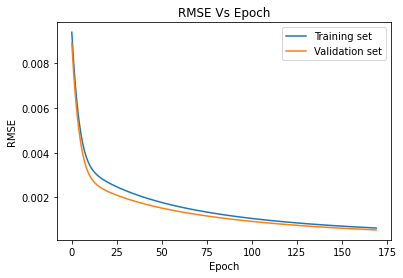

In [ ]:
import matplotlib.pyplot as plt

plt.plot(rmse_train_gd, label='Training set')
plt.plot(rmse_val_gd, label='Validation set')

plt.title('RMSE Vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('RMSE')

plt.legend()

## Part 4 - Mini-batch and Stochastic Gradient Descent [4 marks]

Write a function that performs mini-batch gradient descent until the convergence threshold (CT) is reached. **[1]**

The inputs of that function are: 
  * Input data (training/validation), Batch size, Learning Rate, Convergence Threshold (CT)

Your function will return the following arrays: 
 * The final weights after training.
 * The training RMSE at each epoch.
 * The validation RMSE at each epoch.
 * An array that has the elapsed time from the start of the training process to the end of each epoch (e.g., if each epoch takes exactly 2 seconds, the array would look like: [2 4 6 8 ...]).

Notes: 
* For certain batch sizes, GD might not converge to a solution. For that reason, you need to check the RMSE of the validation/training set at each epoch, and if it's getting larger and larger, you should stop the training for that case (the design is up to you!).
* CT will help you to know when your model is converged. 
* **Important: after each epoch, you need to shuffle the entire training set.** This ensures that new mini-batches are selected for every epoch. Hint: use `np.random.permutation`. 

Let's now use the function to investigate the effect of batch size on convergence. When the batch size is 1, we call that stochastic gradient descent. When the batch size equals the # of training data, it is full-batch (i.e., all data points are used at every iteration). Anywhere in between is mini-batch (we use some of the data).
  * Sweep different values for the mini-batch size (at least 5 values that **converge**), each time using a learning rate of $\alpha= 0.01$. **Hint: Try batch sizes that are powers of two (e.g., 2,4,8,16,32,64,128...).** These batch sizes fit better on the hardware and may achieve higher performance.  **[0.5]**

Provide the following $3$ plots:
  1.  Plot training and validation RMSE vs. **epoch** for all the **converging** batch sizes (some batch sizes might not converge) in a figure. The X-axis is Epoch # and the Y-axis is RMSE. **[0.5]**
  2. Plot training and validation RMSE vs. **time** for all the **converging** batch sizes in a figure. The X-axis is Time, and the Y-axis is RMSE. **[0.5]**
  3. Plot Total training time (y-axis) vs. Batch size (x-axis). **[0.5]**

Describe your findings, including the main takeaways from each of your plots. **[1]**

**From the training and validation RMSE Vs Epoch graphs, we can see that when the batch size is low, the number of epochs it takes to converge is lower as well as the number of iterations per epoch is high for these models. As the batch size increases, the number of epochs it takes to converge increases as well as the number of iterations per epoch is lower for these models. Furthermore, in general, we can see that as the number of epochs increases, both the training and validation RMSE decreases. We can also see that when the batch size is low, the initial RMSE is also low when compared to the models with higher batch sizes.**

**From the training and validation RMSE Vs Time graphs, we can see that, in general, the models having lower batch size are taking less time to converge than the models having a higher batch size. Also, higher batch size models have steeper decrease meaning higher slope values and lower batch size models have reasonble decrease meaning lower slope values. Furthermore, in general we can see that as the time increases, both the training and validation RMSE decreases.**

**Thus, the main takeaways from the plots are that when appropriate batch sizes are chosen, the number of epochs as well as the time it takes for the model to converge is lower than the model having a bigger batch size.**

In [ ]:

def minibatchGD(xtrain, xvalid, ytrain, yvalid, size, alpha, threshold, weights_mbgd):

  batch_no= int(np.ceil(len(xtrain)/size))
  
  xtrain_batch= np.array_split(xtrain, batch_no)
  ytrain_batch= np.array_split(ytrain, batch_no)

  rmse_train_mbgd=[]
  rmse_val_mbgd=[]
  epoch_time=[0]
  epoch=1

  target_ytrain= ytrain.values.reshape(-1,1)
  target_yvalid= yvalid.values.reshape(-1,1)
  
  while True:
    
    start= time.time()
    
    for i in range(int(batch_no)):

      y_pred_train_mbgd= np.dot(xtrain_batch[i], weights_mbgd.T)
                  
      gradient = (1/len(y_pred_train_mbgd) * np.dot(xtrain_batch[i].T, y_pred_train_mbgd-ytrain_batch[i])).reshape(1,-1)
      weights_mbgd = weights_mbgd - alpha * gradient
             
    y_pred_train_mbgd= np.dot(xtrain, weights_mbgd.T)
    y_pred_val_mbgd= np.dot(xvalid, weights_mbgd.T)
    
    rmse_train_temp_mbgd = np.sqrt(mean_squared_error(target_ytrain, y_pred_train_mbgd))
    rmse_val_temp_mbgd = np.sqrt(mean_squared_error(target_yvalid, y_pred_val_mbgd))

    rmse_train_mbgd.append(rmse_train_temp_mbgd)
    rmse_val_mbgd.append(rmse_val_temp_mbgd)

    end=time.time()
    diff= (end-start)+ epoch_time[epoch-1]
    epoch_time.append(diff)  
        
    if(epoch >= 2):
      if(rmse_val_mbgd[epoch-1]> rmse_val_mbgd[epoch-2]):
        comment= 'Diverging'
        return weights_mbgd, rmse_train_mbgd, rmse_val_mbgd, epoch_time[1:], comment
      elif(rmse_val_temp_mbgd <= threshold):
        comment= 'Converging'
        return weights_mbgd, rmse_train_mbgd, rmse_val_mbgd, epoch_time[1:], comment
      else:
        epoch+=1
        index = np.random.permutation(len(xtrain))
        xtrain= xtrain[index]
        ytrain= target_ytrain[index]            
      
    else:
      epoch+=1                 
    

In [ ]:
initial_weights= np.random.uniform(0, 0.001, len(X_train_std_final[0])).reshape(1,-1)

In [ ]:
w_b1, rmse_train_b1, rmse_val_b1, time_b1, state_b1= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, 64, 0.01, 1.001 * rmse_val_ds, initial_weights)
print(state_b1)

Converging


In [ ]:
w_b2, rmse_train_b2, rmse_val_b2, time_b2, state_b2= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, 128, 0.01, 1.001 * rmse_val_ds, initial_weights)
print(state_b2)

Converging


In [ ]:
w_b3, rmse_train_b3, rmse_val_b3, time_b3, state_b3= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, 256, 0.01, 1.001 * rmse_val_ds, initial_weights)
print(state_b3)

Converging


In [ ]:
w_b4, rmse_train_b4, rmse_val_b4, time_b4, state_b4= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, 512, 0.01, 1.001 * rmse_val_ds, initial_weights)
print(state_b4)

Converging


In [ ]:
w_b5, rmse_train_b5, rmse_val_b5, time_b5, state_b5= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, 1024, 0.01, 1.001 * rmse_val_ds, initial_weights)
print(state_b5)

Converging


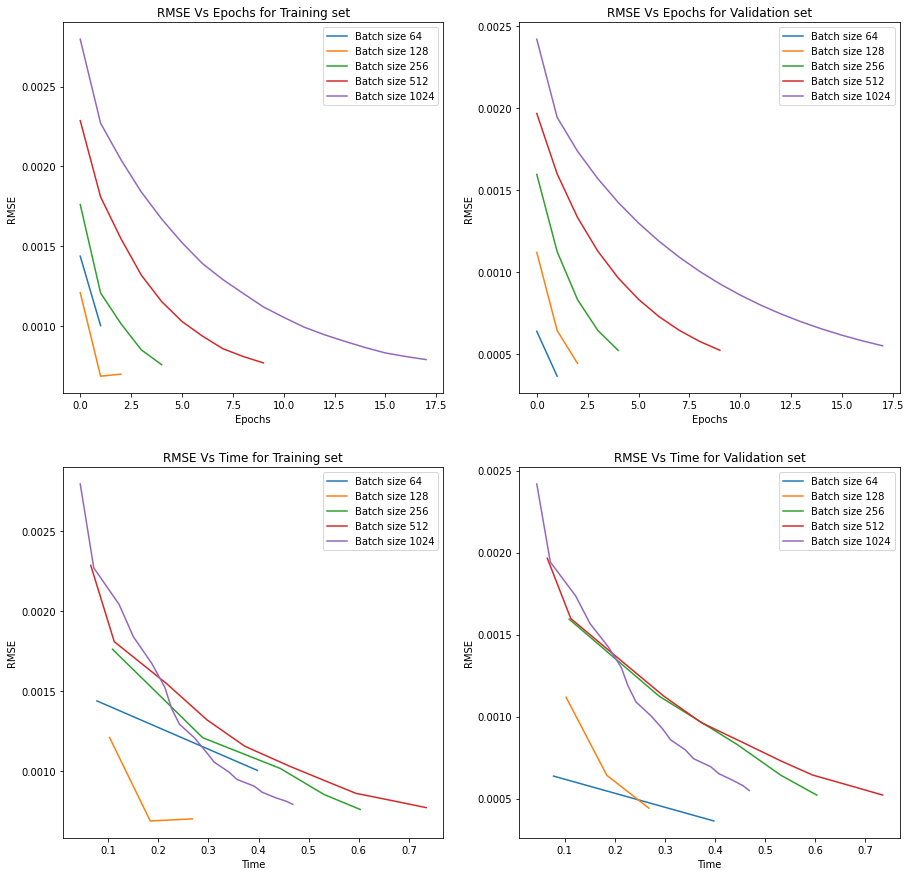

In [ ]:
fig,axes= plt.subplots(2,2,figsize=(15,15))

axes[0,0].plot(rmse_train_b1, label='Batch size 64')
axes[0,0].plot(rmse_train_b2, label='Batch size 128')
axes[0,0].plot(rmse_train_b3, label='Batch size 256')
axes[0,0].plot(rmse_train_b4, label='Batch size 512')
axes[0,0].plot(rmse_train_b5, label='Batch size 1024')

axes[0,0].set(xlabel='Epochs',ylabel='RMSE')
axes[0,0].set_title('RMSE Vs Epochs for Training set')
axes[0,0].legend()

axes[0,1].plot(rmse_val_b1, label='Batch size 64')
axes[0,1].plot(rmse_val_b2, label='Batch size 128')
axes[0,1].plot(rmse_val_b3, label='Batch size 256')
axes[0,1].plot(rmse_val_b4, label='Batch size 512')
axes[0,1].plot(rmse_val_b5, label='Batch size 1024')

axes[0,1].set(xlabel='Epochs',ylabel='RMSE')
axes[0,1].set_title('RMSE Vs Epochs for Validation set')
axes[0,1].legend()

axes[1,0].plot(time_b1, rmse_train_b1, label='Batch size 64')
axes[1,0].plot(time_b2, rmse_train_b2, label='Batch size 128')
axes[1,0].plot(time_b3, rmse_train_b3, label='Batch size 256')
axes[1,0].plot(time_b4, rmse_train_b4, label='Batch size 512')
axes[1,0].plot(time_b5, rmse_train_b5, label='Batch size 1024')

axes[1,0].set(xlabel='Time',ylabel='RMSE')
axes[1,0].set_title('RMSE Vs Time for Training set')
axes[1,0].legend()

axes[1,1].plot(time_b1, rmse_val_b1, label='Batch size 64')
axes[1,1].plot(time_b2, rmse_val_b2, label='Batch size 128')
axes[1,1].plot(time_b3, rmse_val_b3, label='Batch size 256')
axes[1,1].plot(time_b4, rmse_val_b4, label='Batch size 512')
axes[1,1].plot(time_b5, rmse_val_b5, label='Batch size 1024')

axes[1,1].set(xlabel='Time',ylabel='RMSE')
axes[1,1].set_title('RMSE Vs Time for Validation set')
axes[1,1].legend()



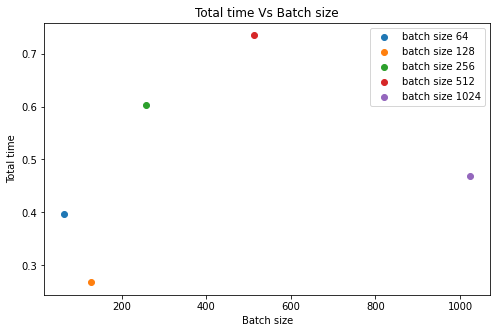

In [ ]:
batch_size = [64,128,256,512,1024]

plt.figure(figsize=(8, 5))

plt.scatter(batch_size[0], time_b1[-1], label='batch size 64')
plt.scatter(batch_size[1], time_b2[-1], label='batch size 128')
plt.scatter(batch_size[2], time_b3[-1], label='batch size 256')
plt.scatter(batch_size[3], time_b4[-1], label='batch size 512')
plt.scatter(batch_size[4], time_b5[-1], label='batch size 1024')

plt.title('Total time Vs Batch size')
plt.xlabel('Batch size')
plt.ylabel('Total time')

plt.legend()

**From the above graph we can see that out of all the batch sizes, the batch size of 128 is the fastest to achieve convergence for this set of random initial weights. However, this keeps varying with initial weights that are varying randomly.**

## Part 5 - Gradient Descent Learning Rate [2 marks]
Use the function that you designed in Part 4 to investigate the effect of learning rate on convergence.

1. Pick 3 batchsize that are not converging with a learning rate of $\alpha= 0.01$ (last part) and try to find a learning rate that results in convergence for each batchsize. Report your findings in a table. Mention batch size, learning rate, and training and validation RMSE. **[0.5]**

2. Select the best batchsize based on Part 4's fastest convergence time and sweep the learning rate (at least 10 values, all should converge) while applying Mini-batch GD. 
  
  * Plot the training and validation RMSE vs. **epoch** (x-axis) for all the learning rates that you tried in a figure. **[0.5]**
  * Plot the training and validation RMSE vs. **time** (x-axis) for all the learning rates that you tried in a figure. **[0.5]**
  * Describe your findings, including the main takeaways from each of your plots. **[0.5]**

**From the training and validation RMSE Vs Epoch graphs for different learning rates, we can see that when the learning rate is low, the number of epochs it takes to converge is higher. As the learning rate increases gradually, we can see that the number of epochs it takes to converge decreases gradually as well. Furthermore, in general, we can see that as the number of epochs increases, both the training and validation RMSE decreases. We can also see that when the learning rate is low, the initial RMSE is high when compared to the models with higher learning rates.**

**From the training and validation RMSE Vs Time graphs, we can see that, in general, the models having lower learning rates are taking more time to converge than the models having a higher learning rate. Furthermore, in general we can see that as the time increases, both the training and validation RMSE decreases.**

**Thus, the main takeaways from the plots are that when an optimal learning rate is chosen, the number of epochs as well as the time it takes for the model to converge is lower than the plot having a low learning rate.**

In [ ]:
# The batch sizes 4, 8 and 16 did not converge for α=0.01. Thus, these 3 batch sizes are chosen for this part.

from tabulate import tabulate

reqd_lr=[]
reqd_train_rmse=[]
reqd_val_rmse=[]
sizes= [4, 8, 16]

for i in sizes:
  
  for j in np.arange(0.010, 0, -0.0005):
    
    w_b, rmse_train_b, rmse_val_b, time_b, state_b= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, i, j, 1.001 * rmse_val_ds, initial_weights)

    if(state_b == 'Converging'):
      reqd_lr.append(j)
      reqd_train_rmse.append(rmse_train_b)
      reqd_val_rmse.append(rmse_val_b)
      break

summary1=[sizes[0], reqd_lr[0], reqd_train_rmse[0][-1], reqd_val_rmse[0][-1]]
summary2=[sizes[1], reqd_lr[1], reqd_train_rmse[1][-1], reqd_val_rmse[1][-1]]
summary3=[sizes[2], reqd_lr[2], reqd_train_rmse[2][-1], reqd_val_rmse[2][-1]]

print(tabulate([summary1, summary2, summary3], headers=['Batch size', 'Learning rate', 'RMSE Training data', 'RMSE Validation data'], tablefmt='fancy_grid'))


╒══════════════╤═════════════════╤══════════════════════╤════════════════════════╕
│   Batch size │   Learning rate │   RMSE Training data │   RMSE Validation data │
╞══════════════╪═════════════════╪══════════════════════╪════════════════════════╡
│            4 │          0.0025 │            0.0133377 │            0.000259157 │
├──────────────┼─────────────────┼──────────────────────┼────────────────────────┤
│            8 │          0.005  │            0.0134461 │            0.000258026 │
├──────────────┼─────────────────┼──────────────────────┼────────────────────────┤
│           16 │          0.01   │            0.0115292 │            0.000252884 │
╘══════════════╧═════════════════╧══════════════════════╧════════════════════════╛


The best batch size is:  128 



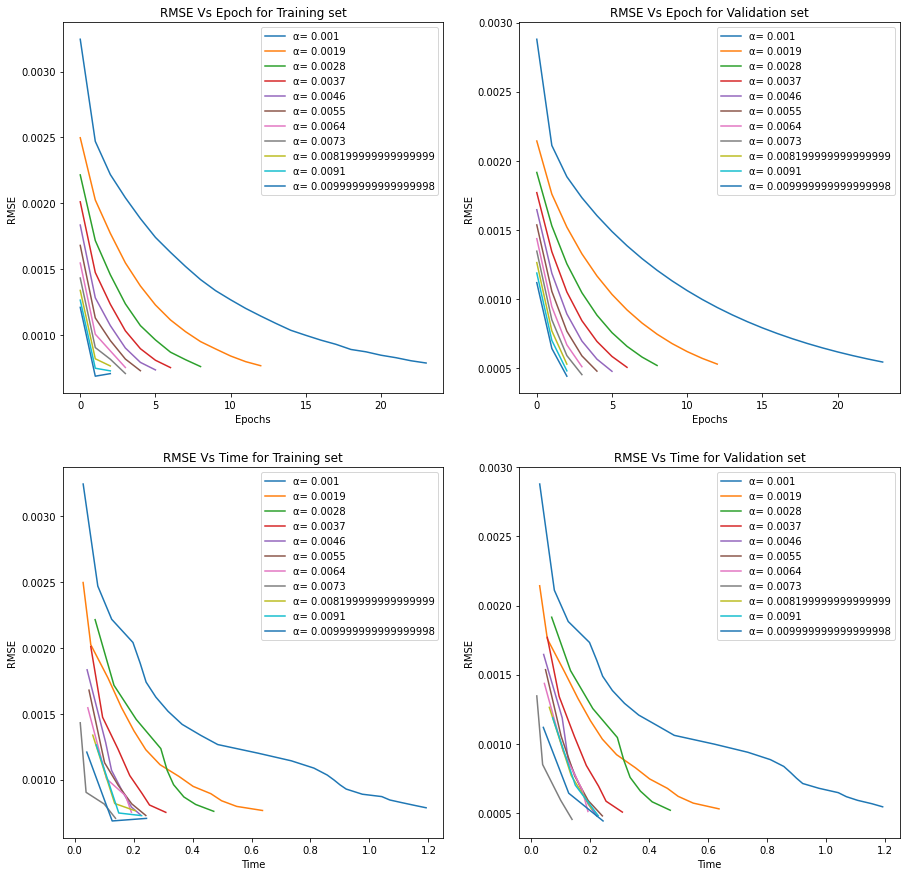

In [ ]:
# The best batch-size based on Part 4's fastest convergence time is chosen using the code below for this part.

time_list=[time_b1[-1],time_b2[-1],time_b3[-1],time_b4[-1],time_b5[-1]] # Grouping together times for different batches in a list
min_time_index= time_list.index(min(time_list)) # Finding min time
best_batch_size= batch_size[min_time_index] # Choosing best batch-size

print('The best batch size is: ', best_batch_size,'\n')
                            
fig1,axes1= plt.subplots(2,2,figsize=(15,15))

axes1[0,0].set(xlabel='Epochs',ylabel='RMSE')
axes1[0,0].set_title('RMSE Vs Epoch for Training set')

axes1[0,1].set(xlabel='Epochs',ylabel='RMSE')
axes1[0,1].set_title('RMSE Vs Epoch for Validation set')

axes1[1,0].set(xlabel='Time',ylabel='RMSE')
axes1[1,0].set_title('RMSE Vs Time for Training set')

axes1[1,1].set(xlabel='Time',ylabel='RMSE')
axes1[1,1].set_title('RMSE Vs Time for Validation set')

for i in np.arange(0.001, 0.01, 0.0009):
  
  w_b, rmse_train_b, rmse_val_b, time_b, state_b= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, best_batch_size, i, 1.001 * rmse_val_ds, initial_weights)

  lr_name= 'α= '+ str(i)

  axes1[0,0].plot(rmse_train_b, label= lr_name)
  axes1[0,1].plot(rmse_val_b, label= lr_name)
  axes1[1,0].plot(time_b, rmse_train_b, label= lr_name)
  axes1[1,1].plot(time_b, rmse_val_b, label= lr_name)

  axes1[0,0].legend()  
  axes1[0,1].legend()  
  axes1[1,0].legend()  
  axes1[1,1].legend()
    

## Part 6 - Finalizing a model [1 marks]
Based on your findings from the previous parts, pick a model (or combination of model settings) that you think would work best for our dataset and evaluate it on the test set. 

Briefly describe your model selections/settings. **[0.5]** **For evaluating our test set, the model that I chose has the following settings:**

**1. For the batch size of the model, I am choosing the size which gives us the fastest convergence time. Since this varies depending on the initial random weights that we start with, I am using a dynamic variable to select the best batch size (Variable name- best_batch_size).**

**2. For the learning rate, from part 5 we can see that when the learning rate is low, the RMSE is high and also our models takes more epochs as well as more time to converge. Thus, from part 5 we can see that the optimal learning rate is 0.01. Thus, I am choosing this setting for our model to evaluate our test data.**

Summarize the performance of your model for the task of managing ailerons of an aircraft. **[0.5]** 

**Based on the RMSE of the test dataset(value= 0.000448923876657945) which is appreciably low as well as comparable to both training and validation RMSE, we can say that our model is performing reasonably good on unknown data and thus we can say that the performance of the model will be appreciable when it is used to design the controller to control the roll of an airplane and to manage the ailerons of an aircraft.**

In [25]:
### YOUR CODE HERE ###

w_test, rmse_train_test, rmse_val_test, time_b_test, state_test= minibatchGD(X_train_std_final, X_val_std_final, y_train, y_val, best_batch_size, 0.01, 1.001 * rmse_val_ds, initial_weights)
y_pred_test = np.dot(X_test_std_final, w_test.T)
 
rmse_test = np.sqrt(mean_squared_error(y_test,y_pred_test))
print('RMSE of test data set is: ', rmse_test)


RMSE of test data set is:  0.000448923876657945


## Part 7 - Getting started with GitHub  [3 marks]

This final part of the project assignment is to be completed independently from Parts 1 - 6. In this part you will be completing some additional coding tasks using a different dataset and submitting your results on Github. To access this part of the assignment and upload your answers, you will need to use Github. Please complete the following step-by-step instructions:

 0. Create a Github account and install git for Windows or Mac: 
  * https://git-scm.com/download/win
  * https://git-scm.com/download/mac

 1. Open this link: https://classroom.github.com/a/ZC8Petsq to create your assignment repository in GitHub. You should get a link similar to:
```
https://github.com/APS-1070-2021/f22-project4-git-*********
```
This your private repository to get this part questions and upload your answers. **Copy this link to the text box below to be graded for this part.**

 
 2. Open `Git Bash`, the app you downloaded in step `0`, and set your Email and username by:
```
git config --global user.email “<your-GitHub-email>”
git config --global user.name “<your-GitHub-username>”
```

 3. Create a folder for the course on your computer and `cd` to that. `cd` means `Change Directory`. For example, on a Windows machine, where I have a folder on "C:\aps1070":
 ```
cd c:aps1070
```
 4. Get your assignment by the link you got in step 1:
```
git clone https://github.com/APS-1070-2021/f22-project4-git-*********
```
If this is the first time you are using Git Bash, it will ask you to sign in on GitHub via your browser. 

 5. A new folder should be created in your directory similar to:
```
C:\aps1070\f22-project4-git-********
```
This folder has an `ipynb` notebook which you need to manually upload to colab and answer its questions. 

 6. After you finished working on this notebook, download the notebook from colab and move it to the directory in step 5.

 7. Replace the old notebook with the new one that has your answers. Make sure your completed notebook has the same name as the original notebook you downloaded. 

 8. To submit your work, follow: 
```
cd <your assignment folder>
git add F22_Project_4_git.ipynb
git commit -m “Final Submission”
git push 
```
If you had any problem with pushing your work on GitHub you can try one of following commands:
```
git push --force
or 
git push origin HEAD:main
```

 9. Make sure your submission is ready for grading. Open the private repository link in your browser and make sure you can see your final submission with your latest changes there. **Only you and the teaching team can open that link.** 

**Private Repository Link : <font color='red'>** **https://github.com/APS-1070-2021/f22-project4-git-SudarsanTp**</font>